Kindly name the monthly sales dataset as REP_S_00134_SMRY.csv

In [7]:
from google.colab import files
files.upload()

Saving REP_S_00134_SMRY.csv to REP_S_00134_SMRY (1).csv


{'REP_S_00134_SMRY (1).csv': b'\xef\xbb\xbfStories,,,,,,,,,,,,,\nComparative Monthly Sales ,,,,,,,,,,,,,\n22-Jan-2026,,"Year: 2026,2025",,,,,,,,,,Page 1 of,0.01\n,,,January,February,March,April,May,June,July,August,September,,\n2025,Stories - Bir Hasan,,"3,355,705.33","2,842,993.67","2,266,050.67","3,459,979.67","2,125,379.33","744,638.33","3,799,740.25","3,783,897.91","3,255,935.75",,\n,Stories Ain El Mreisseh,,"12,648,546.67","9,929,973.33","9,849,926.67","13,025,923.33","7,208,975.00","2,883,403.33","11,889,329.16","11,610,097.92","11,021,123.75",,\n,Stories Airport,,0.00,0.00,0.00,0.00,0.00,"8,428.83","2,940,003.01","6,963,426.45","7,467,197.62",,\n,Stories Antelias,,"2,615,854.33","2,139,010.67","3,162,716.67","3,391,741.33","2,033,635.67","728,978.33","2,963,696.71","3,182,363.97","2,909,965.47",,\n,Stories Batroun,,"4,266,517.33","3,388,117.33","4,890,198.33","5,516,881.67","2,963,980.33","1,311,240.00","6,135,003.02","6,751,770.29","5,041,150.76",,\n,Stories Bayada,,"4,497,376.

In [8]:
# CLEANING CODE for REP_S_00134_SMRY.csv (Comparative Monthly Sales)
# Output: tidy table with columns: year, branch, month, month_num, sales

import re
import numpy as np
import pandas as pd

MONTHS_FULL = ["January","February","March","April","May","June","July","August","September","October","November","December"]
MONTH_NUM = {m:i+1 for i,m in enumerate(MONTHS_FULL)}

def _clean_num(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    s = str(x).strip().replace(",", "")
    if s in ["", "########", "nan", "None"]:
        return np.nan
    return pd.to_numeric(s, errors="coerce")

def clean_rep_s_00134(path="REP_S_00134_SMRY.csv"):
    # Read raw (POS export style)
    df = pd.read_csv(path, header=None, dtype=str, engine="python")
    df = df.dropna(how="all").copy().reset_index(drop=True)

    # Drop obvious junk rows (title/date/page lines)
    def is_junk_row(row):
        s = " ".join([str(v) for v in row.values if pd.notna(v)]).strip()
        if s == "":
            return True
        junk_patterns = [
            r"^Stories$",
            r"Comparative Monthly Sales",
            r"^\d{1,2}-[A-Za-z]{3}-\d{2}$",   # 22-Jan-26
            r"Year:\s*\d{4}",                # Year: 2026,2025
            r"Years?:\s*\d{4}",
            r"Page\s+\d+\s+of",
        ]
        return any(re.search(p, s, flags=re.IGNORECASE) for p in junk_patterns)

    df = df[~df.apply(is_junk_row, axis=1)].copy().reset_index(drop=True)

    # Helper: detect if a row is a month header row (contains several month names)
    def month_header_info(row):
        vals = [str(v).strip() for v in row.values if pd.notna(v)]
        # Find which months appear exactly in this row
        present = [m for m in MONTHS_FULL if any(str(v).strip().lower() == m.lower() for v in vals)]
        if len(present) >= 3:  # enough to be a header
            # map month -> column index
            mapping = {}
            for j, cell in enumerate(row.values):
                cell_str = str(cell).strip() if pd.notna(cell) else ""
                for m in MONTHS_FULL:
                    if cell_str.lower() == m.lower():
                        mapping[m] = j
            return mapping
        return None

    rows_out = []
    current_year = None
    current_month_to_col = None

    i = 0
    while i < len(df):
        row = df.iloc[i]

        # If this is a month-header row, update current mapping
        mh = month_header_info(row)
        if mh is not None:
            current_month_to_col = mh
            i += 1
            continue

        # If we don't yet have a month mapping, skip until we find it
        if current_month_to_col is None:
            i += 1
            continue

        # Parse year + branch from first columns (your file uses col0 year, col1 branch)
        c0 = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ""
        c1 = str(row.iloc[1]).strip() if len(row) > 1 and pd.notna(row.iloc[1]) else ""

        # Year may appear in col0, and branch in col1; subsequent lines can have blank year.
        if re.fullmatch(r"\d{4}", c0):
            current_year = int(c0)
            branch_raw = c1
        else:
            branch_raw = c1  # year continues from above

        # Skip if no year known yet
        if current_year is None:
            i += 1
            continue

        # Some rows are totals or empty branch rows
        if branch_raw is None or str(branch_raw).strip() == "" or str(branch_raw).strip().lower() == "total":
            i += 1
            continue

        # Normalize branch name
        branch = str(branch_raw).strip()
        branch = re.sub(r"^Stories\s*-\s*", "", branch, flags=re.IGNORECASE)
        branch = re.sub(r"^Stories\s+", "", branch, flags=re.IGNORECASE)
        branch = branch.strip()

        # Extract sales for each month in the active header mapping
        for m, col_idx in current_month_to_col.items():
            if col_idx >= len(row):
                continue
            val = _clean_num(row.iloc[col_idx])
            if pd.isna(val):
                continue
            rows_out.append({
                "year": current_year,
                "branch": branch,
                "month": m,
                "month_num": MONTH_NUM[m],
                "sales": val
            })

        i += 1

    out = pd.DataFrame(rows_out)

    # Optional: remove obvious duplicates (can happen because headers repeat and blocks repeat)
    out = out.drop_duplicates(subset=["year","branch","month_num"], keep="last").copy()

    # Sort nicely
    out = out.sort_values(["year","branch","month_num"]).reset_index(drop=True)
    return out


# ---- RUN IT ----
monthly_clean = clean_rep_s_00134("REP_S_00134_SMRY.csv")
monthly_clean.head(600)

,year,branch,month,month_num,sales
0,2025,Ain El Mreisseh,January,1,12648546.67
1,2025,Ain El Mreisseh,February,2,9929973.33
2,2025,Ain El Mreisseh,March,3,9849926.67
3,2025,Ain El Mreisseh,April,4,13025923.33
4,2025,Ain El Mreisseh,May,5,7208975.00
...,...,...,...,...,...
571,2026,sin el fil,August,8,0.00
572,2026,sin el fil,September,9,0.00
573,2026,sin el fil,October,10,0.00
574,2026,sin el fil,November,11,0.00


In [9]:
import os
os.listdir()

['.config',
 'REP_S_00134_SMRY.csv',
 'REP_S_00134_SMRY (1).csv',
 'monthly_sales_clean.csv',
 'sample_data']

In [10]:
print("====== VALIDATION: CLEAN MONTHLY DATA ======")

# Basic structure
print(f"Rows: {len(monthly_clean)}")
print(f"Columns: {list(monthly_clean.columns)}")

# Required columns check (LONG FORMAT)
required_cols = ["year", "branch", "month", "month_num", "sales"]
missing = [c for c in required_cols if c not in monthly_clean.columns]

if missing:
    print("❌ Missing required columns:", missing)
else:
    print("✅ All required columns present")

# Year validation
valid_years = {2025, 2026}
bad_years = set(monthly_clean["year"]) - valid_years

if bad_years:
    print("❌ Invalid year values found:", bad_years)
else:
    print("✅ Year values valid (2025 / 2026)")

# Month validation
valid_months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

bad_months = set(monthly_clean["month"]) - set(valid_months)
if bad_months:
    print("❌ Invalid month names:", bad_months)
else:
    print("✅ Month names valid")

# Month number validation
if monthly_clean["month_num"].between(1,12).all():
    print("✅ Month numbers valid (1–12)")
else:
    print("❌ Invalid month numbers detected")

# Sales validation
if (monthly_clean["sales"] < 0).any():
    print("❌ Negative sales values found")
else:
    print("✅ Sales values non-negative")

# Missing values
nulls = monthly_clean.isna().sum()
if nulls.any():
    print("❌ Missing values detected:")
    print(nulls[nulls > 0])
else:
    print("✅ No missing values")

# Duplicate check
dupes = monthly_clean.duplicated(
    subset=["year", "branch", "month"]
).sum()

if dupes > 0:
    print(f"❌ Duplicate (year, branch, month) rows: {dupes}")
else:
    print("✅ No duplicate (year, branch, month) rows")

# Branch check
branch_count = monthly_clean["branch"].nunique()
print(f"✅ Number of unique branches: {branch_count}")

print("====== VALIDATION COMPLETE ======")

====== VALIDATION: CLEAN MONTHLY DATA ======
Rows: 576
Columns: ['year', 'branch', 'month', 'month_num', 'sales']
✅ All required columns present
✅ Year values valid (2025 / 2026)
✅ Month names valid
✅ Month numbers valid (1–12)
✅ Sales values non-negative
✅ No missing values
✅ No duplicate (year, branch, month) rows
✅ Number of unique branches: 25
====== VALIDATION COMPLETE ======


In [11]:
monthly_clean.to_csv("monthly_sales_clean.csv", index=False)

from google.colab import files
files.download("monthly_sales_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import pandas as pd
import numpy as np

# change this to your dataframe name
df = monthly_clean.copy()

# make sure types are correct
df["year"] = df["year"].astype(int)
df["month_num"] = df["month_num"].astype(int)
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")

# create a proper month date
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month_num"].astype(str) + "-01")

# aggregate across ALL branches
ts = (df.groupby("date", as_index=False)["sales"]
        .sum()
        .sort_values("date")
        .reset_index(drop=True))

ts.head()

,date,sales
0,2025-01-01,67369943.86
1,2025-02-01,57262019.67
2,2025-03-01,64386929.03
3,2025-04-01,81285567.99
4,2025-05-01,44505440.67


In [13]:
print("Months:", len(ts))
print("Date range:", ts["date"].min(), "→", ts["date"].max())

# Check missing months
all_months = pd.date_range(ts["date"].min(), ts["date"].max(), freq="MS")
missing = all_months.difference(ts["date"])
print("Missing months:", list(missing))

Months: 24
Date range: 2025-01-01 00:00:00 → 2026-12-01 00:00:00
Missing months: []


In [14]:
train = ts[ts["date"] < "2026-01-01"].copy()
test  = ts[ts["date"] >= "2026-01-01"].copy()

print("Train months:", len(train))
print("Test months:", len(test))
train.tail(), test

Train months: 12
Test months: 12


(         date         sales
 7  2025-08-01  1.094253e+08
 8  2025-09-01  9.182079e+07
 9  2025-10-01  1.027917e+08
 10 2025-11-01  9.693210e+07
 11 2025-12-01  9.672847e+07,
          date        sales
 12 2026-01-01  62525672.04
 13 2026-02-01         0.00
 14 2026-03-01         0.00
 15 2026-04-01         0.00
 16 2026-05-01         0.00
 17 2026-06-01         0.00
 18 2026-07-01         0.00
 19 2026-08-01         0.00
 20 2026-09-01         0.00
 21 2026-10-01         0.00
 22 2026-11-01         0.00
 23 2026-12-01         0.00)

In [15]:
# Keep only months with real (non-zero) sales
ts_real = ts[ts["sales"] > 0].copy()

print("Real months:", len(ts_real))
print(ts_real.tail())

Real months: 13
         date         sales
8  2025-09-01  9.182079e+07
9  2025-10-01  1.027917e+08
10 2025-11-01  9.693210e+07
11 2025-12-01  9.672847e+07
12 2026-01-01  6.252567e+07


In [16]:
train = ts_real.iloc[:-3]
test  = ts_real.iloc[-3:]

print("Train months:", len(train))
print("Test months:", len(test))

train.tail(), test

Train months: 10
Test months: 3


(        date         sales
 5 2025-06-01  1.843739e+07
 6 2025-07-01  8.962976e+07
 7 2025-08-01  1.094253e+08
 8 2025-09-01  9.182079e+07
 9 2025-10-01  1.027917e+08,
          date        sales
 10 2025-11-01  96932101.85
 11 2025-12-01  96728472.45
 12 2026-01-01  62525672.04)

In [18]:
import pandas as pd
import numpy as np

# Start from your real monthly dataset
ts_feat = ts_real.copy()

# Create lag features
ts_feat["lag_1"] = ts_feat["sales"].shift(1)
ts_feat["lag_2"] = ts_feat["sales"].shift(2)
ts_feat["lag_3"] = ts_feat["sales"].shift(3)

# Rolling averages
ts_feat["roll3_mean"] = ts_feat["sales"].rolling(3).mean()
ts_feat["roll6_mean"] = ts_feat["sales"].rolling(6).mean()

# Drop rows with NaNs caused by lagging
ts_feat = ts_feat.dropna().reset_index(drop=True)

ts_feat.head()

,date,sales,lag_1,lag_2,lag_3,roll3_mean,roll6_mean
0,2025-06-01,1.843739e+07,4.450544e+07,8.128557e+07,64386929.03,4.807613e+07,5.554121e+07
1,2025-07-01,8.962976e+07,1.843739e+07,4.450544e+07,81285567.99,5.085753e+07,5.925118e+07
2,2025-08-01,1.094253e+08,8.962976e+07,1.843739e+07,44505440.67,7.249748e+07,6.794507e+07
3,2025-09-01,9.182079e+07,1.094253e+08,8.962976e+07,18437385.48,9.695862e+07,7.251738e+07
4,2025-10-01,1.027917e+08,9.182079e+07,1.094253e+08,89629757.37,1.013459e+08,7.610173e+07


In [21]:
prophet_df = ts_real.rename(columns={
    "date": "ds",
    "sales": "y"
})

In [22]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(prophet_df)

INFO:prophet:n_changepoints greater than number of observations. Using 9.


In [23]:
future = model.make_future_dataframe(periods=6, freq="MS")
forecast = model.predict(future)

In [24]:
globals().keys()


dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'files', '_1', '_i2', 're', 'np', 'pd', 'MONTHS_FULL', 'MONTH_NUM', '_clean_num', 'clean_rep_s_00134', 'monthly_clean', '_2', '_i3', 'os', '_3', '_i4', 'required_cols', 'missing', 'valid_years', 'bad_years', 'valid_months', 'bad_months', 'nulls', 'dupes', 'branch_count', '_i5', '_i6', '_i7', '_7', '_i8', '_8', '_i9', '_9', '_i10', '_i11', '_i12', 'df', 'ts', '_12', '_i13', 'all_months', '_i14', 'train', 'test', '_14', '_i15', 'ts_real', '_i16', '_16', '_i17', 'mean_absolute_error', 'mean_squared_error', '_i18', 'ts_feat', '_18', '_i19', 'X_train', 'y_train', 'X_test', 'y_test', '_i20', 'future_steps', 'last_row', 'future_rows', 'new_row', 'X_new', '_i21', 'prophet_df', '_i22', 'Prophet', 'model', '_22', '_i23', 'future', 'forecast', '_i24'])

the cleaned version is in your downloads ,upload it here .

In [25]:
from google.colab import files
files.upload()


Saving monthly_sales_clean.csv to monthly_sales_clean (1).csv


{'monthly_sales_clean (1).csv': b'year,branch,month,month_num,sales\n2025,Ain El Mreisseh,January,1,12648546.67\n2025,Ain El Mreisseh,February,2,9929973.33\n2025,Ain El Mreisseh,March,3,9849926.67\n2025,Ain El Mreisseh,April,4,13025923.33\n2025,Ain El Mreisseh,May,5,7208975.0\n2025,Ain El Mreisseh,June,6,2883403.33\n2025,Ain El Mreisseh,July,7,11889329.16\n2025,Ain El Mreisseh,August,8,11610097.92\n2025,Ain El Mreisseh,September,9,11021123.75\n2025,Ain El Mreisseh,October,10,10516783.81\n2025,Ain El Mreisseh,November,11,9387782.61\n2025,Ain El Mreisseh,December,12,9640996.43\n2025,Airport,January,1,0.0\n2025,Airport,February,2,0.0\n2025,Airport,March,3,0.0\n2025,Airport,April,4,0.0\n2025,Airport,May,5,0.0\n2025,Airport,June,6,8428.83\n2025,Airport,July,7,2940003.01\n2025,Airport,August,8,6963426.45\n2025,Airport,September,9,7467197.62\n2025,Airport,October,10,8414672.7\n2025,Airport,November,11,7029720.14\n2025,Airport,December,12,6604828.86\n2025,Antelias,January,1,2615854.33\n2025,An

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("monthly_sales_clean.csv")
df.head()

,year,branch,month,month_num,sales
0,2025,Ain El Mreisseh,January,1,12648546.67
1,2025,Ain El Mreisseh,February,2,9929973.33
2,2025,Ain El Mreisseh,March,3,9849926.67
3,2025,Ain El Mreisseh,April,4,13025923.33
4,2025,Ain El Mreisseh,May,5,7208975.00


In [28]:
df["year"] = df["year"].astype(int)
df["month_num"] = df["month_num"].astype(int)
df["sales"] = pd.to_numeric(df["sales"], errors="coerce").fillna(0)

In [29]:
df["date"] = pd.to_datetime(
    dict(year=df["year"], month=df["month_num"], day=1)
)

In [30]:
ts = (
    df.groupby("date", as_index=False)["sales"]
      .sum()
      .sort_values("date")
      .reset_index(drop=True)
)

print("Months:", len(ts))
print("Range:", ts["date"].min().date(), "->", ts["date"].max().date())
ts.head()

Months: 24
Range: 2025-01-01 -> 2026-12-01


,date,sales
0,2025-01-01,67369943.86
1,2025-02-01,57262019.67
2,2025-03-01,64386929.03
3,2025-04-01,81285567.99
4,2025-05-01,44505440.67


Months in history: 13
Date range: 2025-01-01 -> 2026-01-01


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

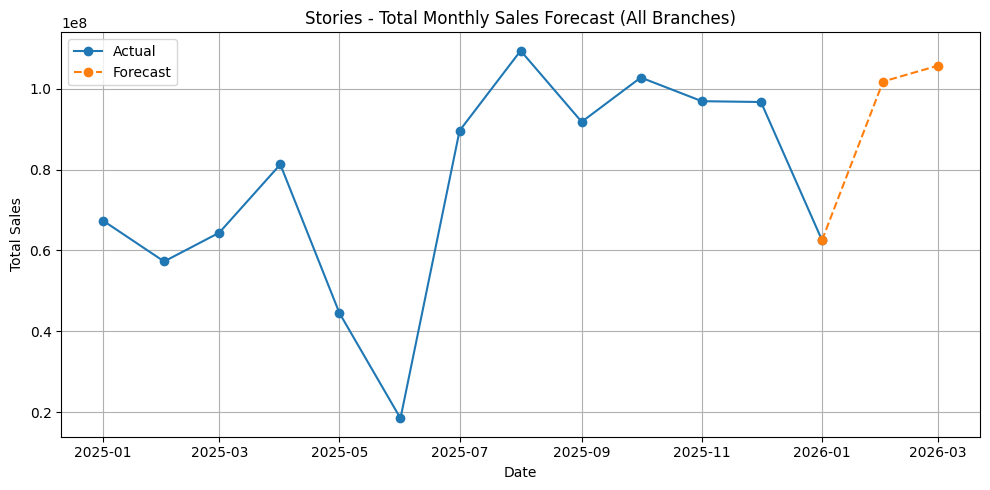

(         Date         sales
 8  2025-09-01  9.182079e+07
 9  2025-10-01  1.027917e+08
 10 2025-11-01  9.693210e+07
 11 2025-12-01  9.672847e+07
 12 2026-01-01  6.252567e+07,
         Date  Predicted_Sales
 0 2026-02-01     1.018050e+08
 1 2026-03-01     1.057476e+08)

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1) Load cleaned monthly data ----------
df = pd.read_csv("monthly_sales_clean.csv")

df["year"] = df["year"].astype(int)
df["month_num"] = df["month_num"].astype(int)
df["sales"] = pd.to_numeric(df["sales"], errors="coerce").fillna(0)

df["Date"] = pd.to_datetime(dict(year=df["year"], month=df["month_num"], day=1))

# ---------- 2) Total sales across ALL branches ----------
hist = (
    df.groupby("Date", as_index=False)["sales"].sum()
      .sort_values("Date")
      .reset_index(drop=True)
)

# Remove fake future months (usually all zeros)
if (hist["sales"] > 0).any():
    last_real_idx = hist.index[hist["sales"] > 0].max()
    hist = hist.loc[:last_real_idx].copy()

print("Months in history:", len(hist))
print("Date range:", hist["Date"].min().date(), "->", hist["Date"].max().date())

# ---------- 3) Forecast next N months ----------
steps = 2   # change to 3 if you want

from statsmodels.tsa.holtwinters import ExponentialSmoothing

y = hist["sales"].values

if len(y) < 6:
    forecast = np.repeat(y[-1], steps)
else:
    model = ExponentialSmoothing(
        y,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    )
    fit = model.fit(optimized=True)
    forecast = fit.forecast(steps)

future_dates = pd.date_range(hist["Date"].max() + pd.offsets.MonthBegin(1),
                             periods=steps, freq="MS")
forecast_df = pd.DataFrame({"Date": future_dates, "Predicted_Sales": forecast})

# ---------- 4) CONNECT the forecast line to last actual ----------
anchor_date = hist["Date"].iloc[-1]
anchor_sales = hist["sales"].iloc[-1]

forecast_connected = pd.concat(
    [
        pd.DataFrame({"Date": [anchor_date], "Predicted_Sales": [anchor_sales]}),
        forecast_df
    ],
    ignore_index=True
)

# ---------- 5) Plot ----------
plt.figure(figsize=(10, 5))

plt.plot(hist["Date"], hist["sales"], marker="o", label="Actual")
plt.plot(
    forecast_connected["Date"],
    forecast_connected["Predicted_Sales"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Stories - Total Monthly Sales Forecast (All Branches)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("total_monthly_sales_forecast.png", dpi=300, bbox_inches="tight")
plt.savefig("total_monthly_sales_forecast.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("total_monthly_sales_forecast.png")
plt.show()

hist.tail(), forecast_df